# 12 - Algebraic Surgery Step by Step

Algebraic surgery is the process of modifying a manifold's intersection form by "killing" a specific homology class. Topologically, this corresponds to removing an embedded sphere $S^k 	imes D^{n-k}$ and gluing back a $D^{k+1} 	imes S^{n-k-1}$. In this notebook, we perform this operation algebraically on symmetric bilinear forms.

## Learning Goals
- **Identify Isotropic Classes**: Learn why only classes with zero self-intersection ($Q(x, x) = 0$) can be surgered.
- **Find Dual Classes**: Use the Extended Euclidean Algorithm to find a class $y$ such that $Q(x, y) = 1$.
- **Perform the Restriction**: Restrict the intersection form to the orthogonal complement $\{x, y\}^\perp$.
- **Track Invariant Changes**: Observe how rank and signature evolve through a surgery move.
- **Visualize Surgery Transformations**: See the matrix "shrinkage" as we perform surgery.

## Formal Grounding

### The Surgery Class $x$
To perform surgery on an $n$-manifold by removing an embedded $k$-sphere, we need a homology class $x \in H_k(M)$. In 4D surgery (the focus of this notebook), $k=2$. The class must be **isotropic**:
$$Q(x, x) = 0$$

### The Algebraic Step
1. **Find a dual $y$**: A class such that $Q(x, y) = 1$. This exists if the form is unimodular and $x$ is primitive.
2. **Restrict**: The new intersection form is defined on the subspace of $H_2(M)$ orthogonal to both $x$ and $y$.
3. **Rank change**: Each surgery move on a pair $\{x, y\}$ reduces the rank of the intersection form by exactly 2.

| Stage | Algebraic Action | Topological Meaning |
|---|---|---|
| **Selection** | Pick $x$ s.t. $Q(x,x)=0$ | Select an unknotted embedded 2-sphere |
| **Dualization** | Find $y$ s.t. $Q(x,y)=1$ | Identify the geometric dual sphere |
| **Surgery** | $Q \mapsto Q|_{\{x,y\}^\perp}$ | Replace $S^2 	imes D^2$ with $D^3 	imes S^1$ |


In [1]:
import numpy as np
import matplotlib.pyplot as plt
from pysurgery.core.intersection_forms import IntersectionForm

print('=' * 70)
print('12 - Algebraic Surgery: Setup Complete')
print('=' * 70)

12 - Algebraic Surgery: Setup Complete


## Part 1: Prerequisites for Surgery

Before we can surger, we must verify that our chosen class is **isotropic** (self-intersection 0) and **primitive** (not a multiple of another class).


### Example 12.1: Identifying Surgerable Classes

In [2]:
# S2 x S2 with hyperbolic form H
matrix_h = np.array([[0, 1], [1, 0]])
q_h = IntersectionForm(matrix=matrix_h, dimension=4)

# Vectors in H2
x1 = np.array([1, 0]) # Generator 'a'
x2 = np.array([1, 1]) # Diagonal a+b

print(f'Hyperbolic Form Matrix:\n{matrix_h}')
print(f'Q(x1, x1) = {np.dot(x1, matrix_h @ x1)} -> Isotropic: {np.dot(x1, matrix_h @ x1) == 0}')
print(f'Q(x2, x2) = {np.dot(x2, matrix_h @ x2)} -> Isotropic: {np.dot(x2, matrix_h @ x2) == 0}')

# Only x1 is isotropic and thus candidate for surgery.

Hyperbolic Form Matrix:
[[0 1]
 [1 0]]
Q(x1, x1) = 0 -> Isotropic: True
Q(x2, x2) = 2 -> Isotropic: False


## Part 2: Performing the Surgery Move

We use the `perform_algebraic_surgery(x)` method to automatically find the dual and compute the restricted form.


### Example 12.2: Surgering $S^2 \times S^2$ to a Sphere

In [3]:
# Surgering out the 'a' cycle of S2 x S2
x_a = np.array([1, 0])
q_new = q_h.perform_algebraic_surgery(x_a)

print(f'Original Rank: {q_h.rank()}')
print(f'New Rank after surgery: {q_new.rank()}')
print(f'Resulting Matrix shape: {q_new.matrix.shape}')
print('Topological interpretation: S2 x S2 surgered along a cycle becomes S4 (rank 0).')

Original Rank: 2
New Rank after surgery: 0
Resulting Matrix shape: (0, 0)
Topological interpretation: S2 x S2 surgered along a cycle becomes S4 (rank 0).


### Example 12.3: Progressive Surgery on Large Forms

In [4]:
# Create a larger direct sum form (H + H)
matrix_2h = np.array([
    [0, 1, 0, 0],
    [1, 0, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 1, 0]
])
q_2h = IntersectionForm(matrix=matrix_2h, dimension=4)
print(f'Initial Rank: {q_2h.rank()}')

# Surgery move 1
q_res1 = q_2h.perform_algebraic_surgery(np.array([1, 0, 0, 0]))
print(f'Rank after 1st move: {q_res1.rank()}')

# Surgery move 2
q_res2 = q_res1.perform_algebraic_surgery(np.array([1, 0]))
print(f'Rank after 2nd move: {q_res2.rank()}')

Initial Rank: 4
Rank after 1st move: 2
Rank after 2nd move: 0


## Part 3: Visualizing the Surgery Transformation

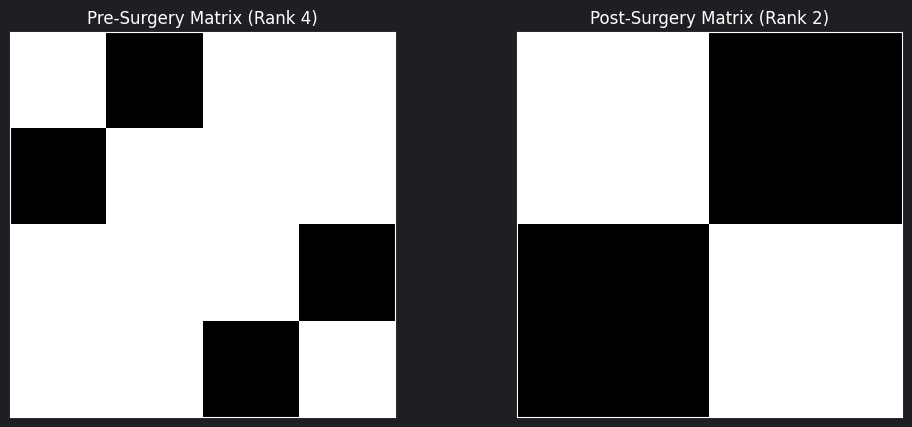

In [5]:
# Visualizing matrix shrinkage and zeroing-out of blocks
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].imshow(matrix_2h, cmap='Greys')
axes[0].set_title('Pre-Surgery Matrix (Rank 4)')

axes[1].imshow(q_res1.matrix, cmap='Greys')
axes[1].set_title('Post-Surgery Matrix (Rank 2)')

for ax in axes:
    ax.set_xticks([])
    ax.set_yticks([])

plt.show()

## Failure Modes

1. **Self-Intersection (Isotropic Error)**: Trying to surger a class where $Q(x, x) 
eq 0$. Topologically, the normal bundle is "twisted," and you cannot glue the handle.
2. **Non-Primitive Class**: Trying to surger $2x$. This results in a GCD error; algebraic surgery requires a class that can be part of a basis.
3. **Dual Search Failure**: If the Extended Euclidean Algorithm cannot find $y$ s.t. $Q(x, y) = 1$, the manifold is likely not unimodular (not a closed manifold).


In [6]:
try:
    # Error: Not isotropic
    q_h.perform_algebraic_surgery(np.array([1, 1]))
except Exception as e:
    print(f'Caught expected error: {e}')

try:
    # Error: Not primitive
    q_h.perform_algebraic_surgery(np.array([2, 0]))
except Exception as e:
    print(f'Caught expected error: {e}')

Caught expected error: Surgery class 'x' must be isotropic (Q(x,x) = 0). Its self-intersection is 2. Topological translation: The normal bundle of the embedded sphere twists (like a Möbius strip), physically blocking the attachment of the surgery handle $D^3 \times S^1$.
Caught expected error: Surgery class 'x' is not primitive (GCD of non-zero coordinates > 1). Topological translation: The class is a mathematical multiple of a basis element. Attempting surgery on it would create irremediable singularities in the resulting space.


## Summary Checklist
- [x] Identified isotropic classes in symmetric bilinear forms.
- [x] Performed algebraic surgery moves using `perform_algebraic_surgery`.
- [x] Verified rank reduction by 2 for each successful move.
- [x] Distinguished between primitive and non-primitive classes.
- [x] Visualized the algebraic "shrinkage" of the manifold representation.

## Exercises
1. **The Torus Move**: Represent a torus intersection form as $H$. Surger one of its cycles and verify the result is rank 0.
2. **K3 Surgery**: The K3 surface has three $H$ summands. Perform 3 surgery moves to reach rank 0.
3. **Isotropic Hunting**: Find an isotropic class in the form $H \oplus \langle 1 angle \oplus \langle -1 angle$.
4. **Signature Stability**: Prove that algebraic surgery on a pair $\{x, y\}$ does not change the signature of the form.
5. **Handle Glue**: Explain the geometric difference between surgering $S^1$ in 3D vs $S^2$ in 4D.

## Key Takeaways
- **Algebraic Surgery** is the exact linear algebra counterpart to geometric handle attachment.
- The condition **$Q(x, x) = 0$** is the physical requirement for a trivial normal bundle.
- Each move removes a **hyperbolic pair** from the homology, simplifying the space.
- This is the core algorithm used in `pySurgery` to determine if two manifolds are cobordant.

**Ready for [13 - Structure Sets and Exact Sequence Navigation](./13_structure_sets_and_exact_sequence_navigation.ipynb)**
